In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [3]:
# Load Iris dataset
iris = load_iris()

# Create DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add actual class names: setosa, versicolor, virginica
df["Species"] = [
    iris.target_names[i] for i in iris.target
]

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
from sklearn.preprocessing import LabelEncoder

In [9]:
encoder = LabelEncoder()

In [11]:
df['Species'] = encoder.fit_transform(df['Species'])

In [13]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
df = df[df['Species'] != 0][['sepal width (cm)','petal length (cm)','Species']] #turing into binary classification and making data complex as seen in pairplot

In [17]:
df.head()

,sepal width (cm),petal length (cm),Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


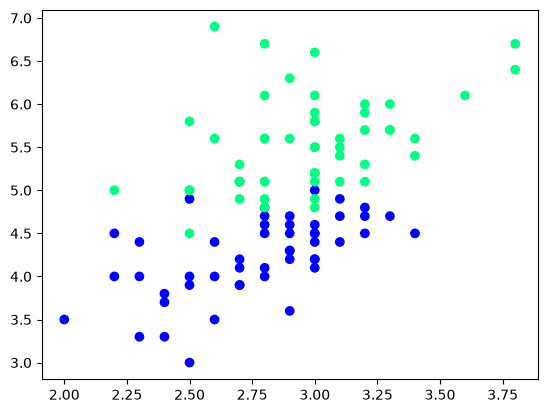

In [19]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['Species'],cmap='winter')

In [21]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [23]:
df_train

,sepal width (cm),petal length (cm),Species
84,3.0,4.5,1
133,2.8,5.1,2
115,3.2,5.3,2
62,2.2,4.0,1
106,2.5,4.5,2
69,2.5,3.9,1
116,3.0,5.5,2
99,2.8,4.1,1
105,3.0,6.6,2
107,2.9,6.3,2


In [25]:
df_val

,sepal width (cm),petal length (cm),Species
139,3.1,5.4,2
74,2.9,4.3,1
140,3.1,5.6,2
111,2.7,5.3,2
88,3.0,4.1,1


In [27]:
df_test

,sepal width (cm),petal length (cm),Species
103,2.9,5.6,2
61,3.0,4.2,1
65,3.1,4.4,1
136,3.4,5.6,2
122,2.8,6.7,2


In [29]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [31]:
y_test

array([2, 1, 2, 2, 1])

# Case 1 - Bagging

In [34]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]
df_bag

,sepal width (cm),petal length (cm),Species
133,2.8,5.1,2
62,2.2,4.0,1
99,2.8,4.1,1
62,2.2,4.0,1
84,3.0,4.5,1
84,3.0,4.5,1
116,3.0,5.5,2
106,2.5,4.5,2


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [40]:
dt_bag1 = DecisionTreeClassifier()

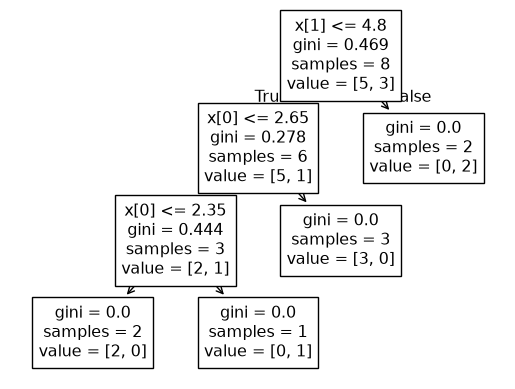

C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


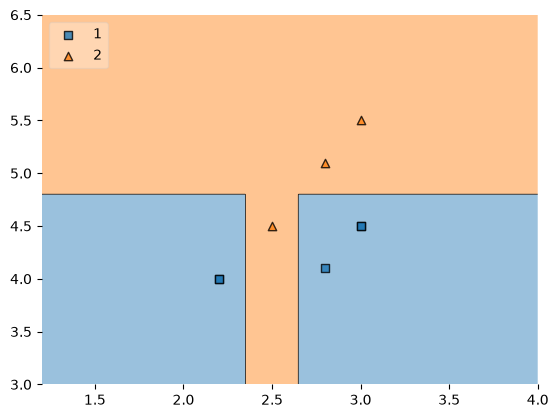

In [46]:
evaluate(dt_bag1,X,y)

In [48]:
# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),Species
99,2.8,4.1,1
62,2.2,4.0,1
84,3.0,4.5,1
106,2.5,4.5,2
99,2.8,4.1,1
62,2.2,4.0,1
99,2.8,4.1,1
107,2.9,6.3,2


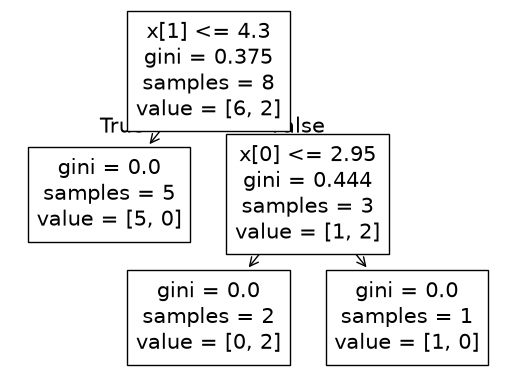

C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


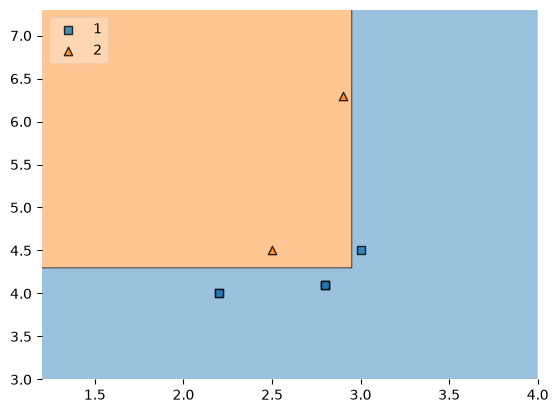

In [50]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [52]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),Species
99,2.8,4.1,1
106,2.5,4.5,2
62,2.2,4.0,1
62,2.2,4.0,1
133,2.8,5.1,2
99,2.8,4.1,1
105,3.0,6.6,2
99,2.8,4.1,1


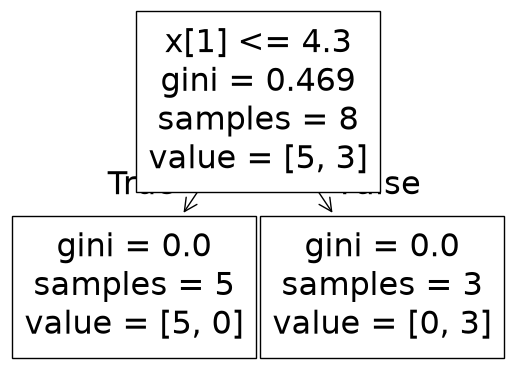

C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


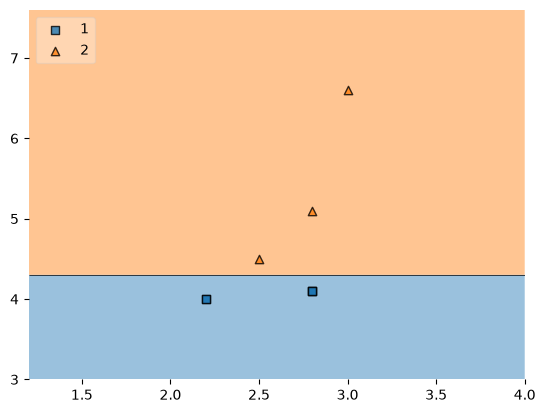

In [54]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

In [44]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))
    

## Predict

In [56]:
df_test

,sepal width (cm),petal length (cm),Species
103,2.9,5.6,2
61,3.0,4.2,1
65,3.1,4.4,1
136,3.4,5.6,2
122,2.8,6.7,2


In [60]:
print("Predictor 1",dt_bag1.predict(np.array([3.0,4.2]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([3.0,4.2]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([3.0,4.2]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Nandika\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting

In [62]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),Species
84,3.0,4.5,1
133,2.8,5.1,2
115,3.2,5.3,2
62,2.2,4.0,1
106,2.5,4.5,2
69,2.5,3.9,1
116,3.0,5.5,2
99,2.8,4.1,1
105,3.0,6.6,2
107,2.9,6.3,2


In [64]:
df_train.sample(8) # replace!=True, not repeated rows

,sepal width (cm),petal length (cm),Species
133,2.8,5.1,2
99,2.8,4.1,1
116,3.0,5.5,2
105,3.0,6.6,2
115,3.2,5.3,2
84,3.0,4.5,1
69,2.5,3.9,1
62,2.2,4.0,1


# Random Subspaces

In [72]:
# columns sampling with or withour replacement
df1 = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df1['Species'] = iris.target
df1 = df1.sample(10)

In [74]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
125,7.2,3.2,6.0,1.8,2
143,6.8,3.2,5.9,2.3,2
92,5.8,2.6,4.0,1.2,1
73,6.1,2.8,4.7,1.2,1
31,5.4,3.4,1.5,0.4,0
108,6.7,2.5,5.8,1.8,2
114,5.8,2.8,5.1,2.4,2
43,5.0,3.5,1.6,0.6,0
55,5.7,2.8,4.5,1.3,1
9,4.9,3.1,1.5,0.1,0


In [80]:
df1.sample(2,replace=True,axis=1)

,petal width (cm),petal length (cm)
125,1.8,6.0
143,2.3,5.9
92,1.2,4.0
73,1.2,4.7
31,0.4,1.5
108,1.8,5.8
114,2.4,5.1
43,0.6,1.6
55,1.3,4.5
9,0.1,1.5


# Random Patches

In [82]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
125,7.2,3.2,6.0,1.8,2
143,6.8,3.2,5.9,2.3,2
92,5.8,2.6,4.0,1.2,1
73,6.1,2.8,4.7,1.2,1
31,5.4,3.4,1.5,0.4,0
108,6.7,2.5,5.8,1.8,2
114,5.8,2.8,5.1,2.4,2
43,5.0,3.5,1.6,0.6,0
55,5.7,2.8,4.5,1.3,1
9,4.9,3.1,1.5,0.1,0


In [84]:
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,petal width (cm),sepal width (cm)
114,2.4,2.8
73,1.2,2.8
108,1.8,2.5
125,1.8,3.2
9,0.1,3.1
114,2.4,2.8
108,1.8,2.5
43,0.6,3.5
